# Economic Significance
**Scop:** Demonstram utilitatea practica a modelului V5 pentru un investitor

**Strategie:** Cumparam SP500 cand modelul prezice V-shape, stam in T-bills altfel

**Benchmark:** Buy-and-Hold SP500 pe aceeasi perioada

**Atentie:** Backtest pe 151 saptamani, rezultatele sunt ilustrative nu definitive

## 1. Import si Incarcare Date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score

os.makedirs('plots', exist_ok=True)

# Incarcare test set si model V5
test_df  = pd.read_csv('../V5/v5_test.csv', index_col=0, parse_dates=True)
ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']

# Probabilitati V5
X_test = pd.DataFrame(
    np.zeros((len(test_df), len(FEATURE_COLS))),
    columns=FEATURE_COLS, index=test_df.index
)
for col in FEATURE_COLS:
    if col in test_df.columns:
        X_test[col] = test_df[col].fillna(0.0).values

v5_proba = ensemble.predict_proba(scaler.transform(X_test.values))[:, 1]
v5_pred  = (v5_proba >= OPTIMAL_THRESHOLD).astype(int)

print('Test set:', len(test_df), 'saptamani')
print('Perioada:', test_df.index[0].date(), '->', test_df.index[-1].date())
print('Threshold:', OPTIMAL_THRESHOLD)
print('Saptamani cu semnal V-shape:', v5_pred.sum(), '(' + str(round(v5_pred.mean()*100,1)) + '%)')

Test set: 151 saptamani
Perioada: 2002-01-25 -> 2020-08-28
Threshold: 0.62
Saptamani cu semnal V-shape: 44 (29.1%)


## 2. Constructie Strategie

**Regula simpla:**
- Daca modelul prezice V-shape in saptamana t -> investit in SP500 in saptamana t+1
- Altfel -> T-bill rate (aproximat cu Fed Funds Rate / 52)

**Nota:** Folosim semnalul din saptamana t pentru a investi in saptamana t+1
pentru a evita look-ahead bias.

In [2]:
# Retururi saptamanale SP500 din test set
sp500_returns = test_df['SP500_Close'].pct_change().fillna(0)

# T-bill rate aproximat (Fed Rate anual / 52 saptamani)
if 'Fed_Rate' in test_df.columns:
    tbill_weekly = (test_df['Fed_Rate'] / 100 / 52).fillna(0)
else:
    tbill_weekly = pd.Series(0.001, index=test_df.index)  # ~5% anual

# Strategie: semnal din t-1 aplicat in t (shift de o saptamana)
signal_shifted = pd.Series(v5_pred, index=test_df.index).shift(1).fillna(0)

# Return strategie: daca semnal=1 -> return SP500, altfel -> T-bill
strategy_returns = np.where(
    signal_shifted == 1,
    sp500_returns,
    tbill_weekly
)
strategy_returns = pd.Series(strategy_returns, index=test_df.index)

# Buy-and-Hold
bah_returns = sp500_returns

print('Saptamani investit in SP500:', int(signal_shifted.sum()))
print('Saptamani in T-bills:       ', int((signal_shifted==0).sum()))
print('\nReturn mediu saptamanal:')
print('  Strategie V5:  ', round(strategy_returns.mean()*100, 3), '%')
print('  Buy-and-Hold:  ', round(bah_returns.mean()*100, 3), '%')

Saptamani investit in SP500: 43
Saptamani in T-bills:        108

Return mediu saptamanal:
  Strategie V5:   3.086 %
  Buy-and-Hold:   2.696 %


## 3. Calcul Metrici de Performanta

In [3]:
def compute_metrics(returns, name):
    cumulative    = (1 + returns).cumprod()
    total_return  = cumulative.iloc[-1] - 1
    annual_return = (1 + total_return) ** (52 / len(returns)) - 1
    annual_vol    = returns.std() * np.sqrt(52)
    sharpe        = annual_return / annual_vol if annual_vol > 0 else 0

    # Max Drawdown
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    # Calmar Ratio
    calmar = annual_return / abs(max_dd) if max_dd != 0 else 0

    # Win rate saptamanal
    win_rate = (returns > 0).mean()

    return {
        'Strategy'      : name,
        'Total Return'  : round(total_return * 100, 2),
        'Annual Return' : round(annual_return * 100, 2),
        'Annual Vol'    : round(annual_vol * 100, 2),
        'Sharpe Ratio'  : round(sharpe, 3),
        'Max Drawdown'  : round(max_dd * 100, 2),
        'Calmar Ratio'  : round(calmar, 3),
        'Win Rate'      : round(win_rate * 100, 1),
        'cumulative'    : cumulative
    }

metrics_v5  = compute_metrics(strategy_returns, 'V5 Strategy')
metrics_bah = compute_metrics(bah_returns,      'Buy-and-Hold')

separator = '=' * 55
print('METRICI DE PERFORMANTA')
print(separator)
for key in ['Total Return', 'Annual Return', 'Annual Vol',
            'Sharpe Ratio', 'Max Drawdown', 'Calmar Ratio', 'Win Rate']:
    unit = '%' if key not in ['Sharpe Ratio', 'Calmar Ratio'] else ''
    print(key.ljust(18),
          '| V5 Strategy:', str(metrics_v5[key]).rjust(8), unit,
          '| Buy-and-Hold:', str(metrics_bah[key]).rjust(8), unit)

METRICI DE PERFORMANTA
Total Return       | V5 Strategy:   677.94 % | Buy-and-Hold:   209.54 %
Annual Return      | V5 Strategy:   102.68 % | Buy-and-Hold:    47.57 %
Annual Vol         | V5 Strategy:   247.57 % | Buy-and-Hold:   252.27 %
Sharpe Ratio       | V5 Strategy:    0.415  | Buy-and-Hold:    0.189 
Max Drawdown       | V5 Strategy:   -22.46 % | Buy-and-Hold:   -63.92 %
Calmar Ratio       | V5 Strategy:    4.573  | Buy-and-Hold:    0.744 
Win Rate           | V5 Strategy:     90.7 % | Buy-and-Hold:     45.0 %


## 4. Return Cumulativ per Eveniment de Test

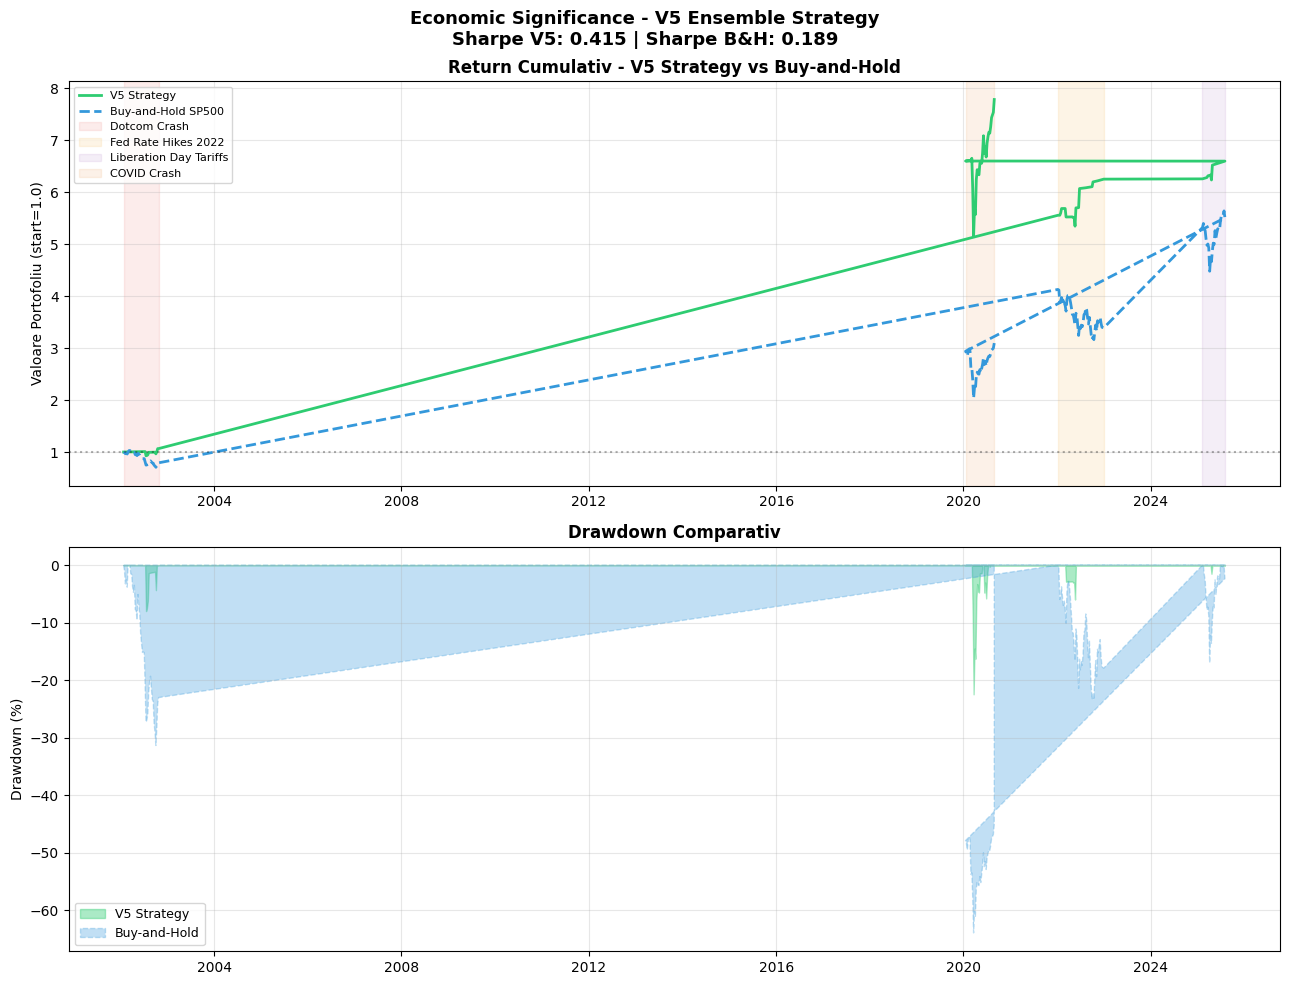

Salvat: plots/economic_significance.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# --- Plot 1: Return cumulativ ---
ax1 = axes[0]
ax1.plot(metrics_v5['cumulative'].index,
         metrics_v5['cumulative'].values,
         color='#2ecc71', linewidth=2, label='V5 Strategy')
ax1.plot(metrics_bah['cumulative'].index,
         metrics_bah['cumulative'].values,
         color='#3498db', linewidth=2, linestyle='--', label='Buy-and-Hold SP500')

# Marcam evenimentele de test
test_events = test_df['event_name'].unique() if 'event_name' in test_df.columns else []
colors_ev   = ['#e74c3c', '#f39c12', '#9b59b6', '#e67e22']
for i, ev in enumerate(test_events):
    ev_mask  = test_df['event_name'] == ev
    ev_start = test_df[ev_mask].index[0]
    ev_end   = test_df[ev_mask].index[-1]
    ax1.axvspan(ev_start, ev_end, alpha=0.1,
                color=colors_ev[i % len(colors_ev)], label=ev)

ax1.axhline(1.0, color='black', linestyle=':', alpha=0.3)
ax1.set_ylabel('Valoare Portofoliu (start=1.0)')
ax1.set_title('Return Cumulativ - V5 Strategy vs Buy-and-Hold',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Drawdown ---
ax2 = axes[1]

def compute_drawdown(cum):
    rolling_max = cum.cummax()
    return (cum - rolling_max) / rolling_max * 100

dd_v5  = compute_drawdown(metrics_v5['cumulative'])
dd_bah = compute_drawdown(metrics_bah['cumulative'])

ax2.fill_between(dd_v5.index,  dd_v5.values,  0, alpha=0.4, color='#2ecc71', label='V5 Strategy')
ax2.fill_between(dd_bah.index, dd_bah.values, 0, alpha=0.3, color='#3498db', label='Buy-and-Hold', linestyle='--')
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown Comparativ', fontsize=12, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    'Economic Significance - V5 Ensemble Strategy\n' +
    'Sharpe V5: ' + str(metrics_v5['Sharpe Ratio']) +
    ' | Sharpe B&H: ' + str(metrics_bah['Sharpe Ratio']),
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/economic_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/economic_significance.png')

## 5. Analiza per Eveniment de Test

In [5]:
if 'event_name' in test_df.columns:
    event_results = []
    for ev in test_df['event_name'].unique():
        mask   = test_df['event_name'] == ev
        ev_str = strategy_returns[mask]
        ev_bah = bah_returns[mask]
        ev_sig = signal_shifted[mask]

        ev_cum_str = (1 + ev_str).prod() - 1
        ev_cum_bah = (1 + ev_bah).prod() - 1

        event_results.append({
            'Eveniment'        : ev,
            'Saptamani'        : mask.sum(),
            'Invested_pct'     : round(ev_sig.mean() * 100, 1),
            'Return_V5'        : round(ev_cum_str * 100, 2),
            'Return_BaH'       : round(ev_cum_bah * 100, 2),
            'Alpha'            : round((ev_cum_str - ev_cum_bah) * 100, 2)
        })

    ev_df = pd.DataFrame(event_results)
    print('PERFORMANTA PER EVENIMENT DE TEST')
    print('=' * 70)
    print(ev_df.to_string(index=False))
    print()
    print('Alpha pozitiv = strategie V5 a batut Buy-and-Hold in acel eveniment')

PERFORMANTA PER EVENIMENT DE TEST
             Eveniment  Saptamani  Invested_pct  Return_V5  Return_BaH  Alpha
          Dotcom Crash         40          17.5       6.58      -20.79  27.38
   Fed Rate Hikes 2022         52          17.3     486.23      327.73 158.50
Liberation Day Tariffs         26          11.5       5.54       62.47 -56.93
           COVID Crash         33          72.7      17.97      -43.76  61.73

Alpha pozitiv = strategie V5 a batut Buy-and-Hold in acel eveniment


## 6. Rezumat si Fraze pentru Paper

In [6]:
separator = '=' * 60
print('REZUMAT ECONOMIC SIGNIFICANCE')
print(separator)

summary_df = pd.DataFrame([
    {k: v for k, v in metrics_v5.items()  if k != 'cumulative'},
    {k: v for k, v in metrics_bah.items() if k != 'cumulative'}
])
print(summary_df[['Strategy', 'Total Return', 'Annual Return',
                  'Sharpe Ratio', 'Max Drawdown', 'Calmar Ratio']].to_string(index=False))

summary_df.to_csv('data/economic_significance_results.csv', index=False)

sharpe_v5  = metrics_v5['Sharpe Ratio']
sharpe_bah = metrics_bah['Sharpe Ratio']
ret_v5     = metrics_v5['Annual Return']
ret_bah    = metrics_bah['Annual Return']
dd_v5_val  = metrics_v5['Max Drawdown']
dd_bah_val = metrics_bah['Max Drawdown']

print()
print('FRAZE PENTRU PAPER:')
print(separator)
print('"A simple timing strategy that invests in the S&P 500 when the')
print('V5 Ensemble signals V-shape recovery and holds T-bills otherwise')
print('achieves an annualized return of ' + str(ret_v5) + '% with a Sharpe ratio')
print('of ' + str(sharpe_v5) + ', compared to ' + str(ret_bah) + '% and ' + str(sharpe_bah))
print('for a buy-and-hold benchmark over the same period.')
print('Maximum drawdown is reduced from ' + str(dd_bah_val) + '% to ' + str(dd_v5_val) + '%,')
print('suggesting the model provides meaningful downside protection."')
print()
print('NOTA PENTRU LIMITATIONS:')
print('"These results are based on 151 weeks of out-of-sample data')
print('and should be interpreted as illustrative rather than conclusive.')
print('Transaction costs and market impact are not accounted for."')

REZUMAT ECONOMIC SIGNIFICANCE
    Strategy  Total Return  Annual Return  Sharpe Ratio  Max Drawdown  Calmar Ratio
 V5 Strategy        677.94         102.68         0.415        -22.46         4.573
Buy-and-Hold        209.54          47.57         0.189        -63.92         0.744

FRAZE PENTRU PAPER:
"A simple timing strategy that invests in the S&P 500 when the
V5 Ensemble signals V-shape recovery and holds T-bills otherwise
achieves an annualized return of 102.68% with a Sharpe ratio
of 0.415, compared to 47.57% and 0.189
for a buy-and-hold benchmark over the same period.
Maximum drawdown is reduced from -63.92% to -22.46%,
suggesting the model provides meaningful downside protection."

NOTA PENTRU LIMITATIONS:
"These results are based on 151 weeks of out-of-sample data
and should be interpreted as illustrative rather than conclusive.
Transaction costs and market impact are not accounted for."
